

# Exporting Epochs to Pandas DataFrames

This tutorial shows how to export the data in :class:`~mne.Epochs` objects to a
:class:`Pandas DataFrame <pandas.DataFrame>`, and applies a typical Pandas
:doc:`split-apply-combine <pandas:user_guide/groupby>` workflow to examine the
latencies of the response maxima across epochs and conditions.

We'll use the `sample-dataset` dataset, but load a version of the raw file
that has already been filtered and downsampled, and has an average reference
applied to its EEG channels. As usual we'll start by importing the modules we
need and loading the data:


In [1]:
# Authors: The MNE-Python contributors.
# License: BSD-3-Clause
# Copyright the MNE-Python contributors.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import mne

sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"
)
raw = mne.io.read_raw_fif(sample_data_raw_file, verbose=False)

Next we'll load a list of events from file, map them to condition names with
an event dictionary, set some signal rejection thresholds (cf.
`tut-reject-epochs-section`), and segment the continuous data into
epochs:



In [3]:
sample_data_events_file = (
    sample_data_folder / "MEG" / "sample" / "sample_audvis_filt-0-40_raw-eve.fif"
)
events = mne.read_events(sample_data_events_file)

event_dict = {
    "auditory/left": 1,
    "auditory/right": 2,
    "visual/left": 3,
    "visual/right": 4,
}

reject_criteria = dict(
    mag=3000e-15,  # 3000 fT
    grad=3000e-13,  # 3000 fT/cm
    eeg=100e-6,  # 100 µV
    eog=200e-6,
)  # 200 µV

tmin, tmax = (-0.2, 0.5)  # epoch from 200 ms before event to 500 ms after it
baseline = (None, 0)  # baseline period from start of epoch to time=0

epochs = mne.Epochs(
    raw,
    events,
    event_dict,
    tmin,
    tmax,
    proj=True,
    baseline=baseline,
    reject=reject_criteria,
    preload=True,
)
del raw

Not setting metadata
288 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 4)
4 projection items activated
Loading data for 288 events and 106 original time points ...
    Rejecting  epoch based on EEG : ['EEG 003']
    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 006', 'EEG 007']
    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']
    Rejecting  epoch based on EEG : ['EEG 001']
    Rejecting  epoch based on EEG : ['EEG 003', 'EEG 007']
    Rejecting  epoch based on EEG : ['EEG 007']
    Rejecting  epoch based on EEG : ['EEG 003', 'EEG 007']
    Rejecting  epoch based on EEG : ['EEG 007']
    Rejecting  epoch based on MAG : ['MEG 1411', 'MEG 1421', 'MEG 1441']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EEG : ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 007']
    Rejecting  e

## Converting an ``Epochs`` object to a ``DataFrame``

Once we have our :class:`~mne.Epochs` object, converting it to a
:class:`~pandas.DataFrame` is simple: just call :meth:`epochs.to_data_frame()
<mne.Epochs.to_data_frame>`. Each channel's data will be a column of the new
:class:`~pandas.DataFrame`, alongside three additional columns of event name,
epoch number, and sample time. Here we'll just show the first few rows and
columns:



In [4]:
df = epochs.to_data_frame()
df.iloc[:5, :10]

,time,condition,epoch,MEG 0113,MEG 0112,MEG 0111,MEG 0122,MEG 0123,MEG 0121,MEG 0132
0,-0.199795,visual/left,1,21.320252,11.567619,-73.248584,-10.609895,-18.700540,-68.352746,-17.908667
1,-0.193135,visual/left,1,7.049675,-9.702938,-34.168267,17.480975,-40.182237,-121.225684,2.072452
2,-0.186476,visual/left,1,5.283711,-13.006895,-26.912317,52.130290,-65.157198,-117.842466,6.986073
3,-0.179816,visual/left,1,23.040471,1.643716,-37.835772,48.517952,-65.214631,-82.043144,9.672744
4,-0.173156,visual/left,1,25.688943,7.974112,-85.561683,6.450115,-43.778315,-111.795987,17.277138


### Scaling time and channel values

By default, time values are converted from seconds to milliseconds and
then rounded to the nearest integer; if you don't want this, you can pass
``time_format=None`` to keep time as a :class:`float` value in seconds, or
convert it to a :class:`~pandas.Timedelta` value via
``time_format='timedelta'``.

Note also that, by default, channel measurement values are scaled so that EEG
data are converted to µV, magnetometer data are converted to fT, and
gradiometer data are converted to fT/cm. These scalings can be customized
through the ``scalings`` parameter, or suppressed by passing
``scalings=dict(eeg=1, mag=1, grad=1)``.



In [5]:
df = epochs.to_data_frame(time_format=None, scalings=dict(eeg=1, mag=1, grad=1))
df.iloc[:5, :10]

,time,condition,epoch,MEG 0113,MEG 0112,MEG 0111,MEG 0122,MEG 0123,MEG 0121,MEG 0132
0,-0.199795,visual/left,1,2.132025e-12,1.156762e-12,-7.324858e-14,-1.060990e-12,-1.870054e-12,-6.835275e-14,-1.790867e-12
1,-0.193135,visual/left,1,7.049675e-13,-9.702938e-13,-3.416827e-14,1.748098e-12,-4.018224e-12,-1.212257e-13,2.072452e-13
2,-0.186476,visual/left,1,5.283711e-13,-1.300690e-12,-2.691232e-14,5.213029e-12,-6.515720e-12,-1.178425e-13,6.986073e-13
3,-0.179816,visual/left,1,2.304047e-12,1.643716e-13,-3.783577e-14,4.851795e-12,-6.521463e-12,-8.204314e-14,9.672744e-13
4,-0.173156,visual/left,1,2.568894e-12,7.974112e-13,-8.556168e-14,6.450115e-13,-4.377831e-12,-1.117960e-13,1.727714e-12


Notice that the time values are no longer integers, and the channel values
have changed by several orders of magnitude compared to the earlier
DataFrame.


### Setting the ``index``

It is also possible to move one or more of the indicator columns (event name,
epoch number, and sample time) into the `index <pandas:indexing>`, by
passing a string or list of strings as the ``index`` parameter. We'll also
demonstrate here the effect of ``time_format='timedelta'``, yielding
:class:`~pandas.Timedelta` values in the "time" column.



In [6]:
df = epochs.to_data_frame(index=["condition", "epoch"], time_format="timedelta")
df.iloc[:5, :10]

time   MEG 0113   MEG 0112  \
condition   epoch                                                     
visual/left 1     -1 days +23:59:59.800204787  21.320252  11.567619   
            1     -1 days +23:59:59.806864627   7.049675  -9.702938   
            1     -1 days +23:59:59.813524468   5.283711 -13.006895   
            1     -1 days +23:59:59.820184308  23.040471   1.643716   
            1     -1 days +23:59:59.826844149  25.688943   7.974112   

                    MEG 0111   MEG 0122   MEG 0123    MEG 0121   MEG 0132  \
condition   epoch                                                           
visual/left 1     -73.248584 -10.609895 -18.700540  -68.352746 -17.908667   
            1     -34.168267  17.480975 -40.182237 -121.225684   2.072452   
            1     -26.912317  52.130290 -65.157198 -117.842466   6.986073   
            1     -37.835772  48.517952 -65.214631  -82.043144   9.672744   
            1     -85.561683   6.450115 -43.778315 -111.795987  17.277138   

                    MEG 0133    MEG 0131  
condition   epoch                         
visual/left 1      45.379736  -53.123525  
            1      27.734826  -95.339465  
            1       5.996158 -177.627037  
            1       1.748030 -211.024973  
            1       2.123811 -173.917677

### Wide- versus long-format DataFrames

Another parameter, ``long_format``, determines whether each channel's data
is in a separate column of the :class:`~pandas.DataFrame`
(``long_format=False``), or whether the measured values are pivoted into a
single ``'value'`` column with an extra indicator column for the channel name
(``long_format=True``). Passing ``long_format=True`` will also create an
extra column ``ch_type`` indicating the channel type.



In [7]:
long_df = epochs.to_data_frame(time_format=None, index="condition", long_format=True)
long_df.head()

Converting "epoch" to "category"...
Converting "channel" to "category"...
Converting "ch_type" to "category"...


,epoch,time,channel,ch_type,value
condition,,,,,
visual/left,1,-0.199795,MEG 0113,grad,21.320252
visual/left,1,-0.199795,MEG 0112,grad,11.567619
visual/left,1,-0.199795,MEG 0111,mag,-73.248584
visual/left,1,-0.199795,MEG 0122,grad,-10.609895
visual/left,1,-0.199795,MEG 0123,grad,-18.700540


Generating the :class:`~pandas.DataFrame` in long format can be helpful when
using other Python modules for subsequent analysis or plotting. For example,
here we'll take data from the "auditory/left" condition, pick a couple MEG
channels, and use :func:`seaborn.lineplot` to automatically plot the mean and
confidence band for each channel, with confidence computed across the epochs
in the chosen condition:



<Axes: xlabel='time', ylabel='value'>

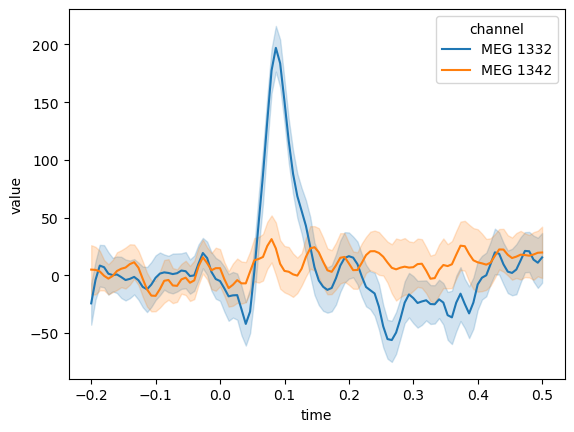

In [8]:
plt.figure()
channels = ["MEG 1332", "MEG 1342"]
data = long_df.loc["auditory/left"].query("channel in @channels")
# convert channel column (CategoryDtype → string; for a nicer-looking legend)
data["channel"] = data["channel"].astype(str)
data.reset_index(drop=True, inplace=True)  # speeds things up
sns.lineplot(x="time", y="value", hue="channel", data=data)

We can also now use all the power of Pandas for grouping and transforming our
data. Here, we find the latency of peak activation of 2 gradiometers (one
near auditory cortex and one near visual cortex), and plot the distribution
of the timing of the peak in each channel as a :func:`~seaborn.violinplot`:



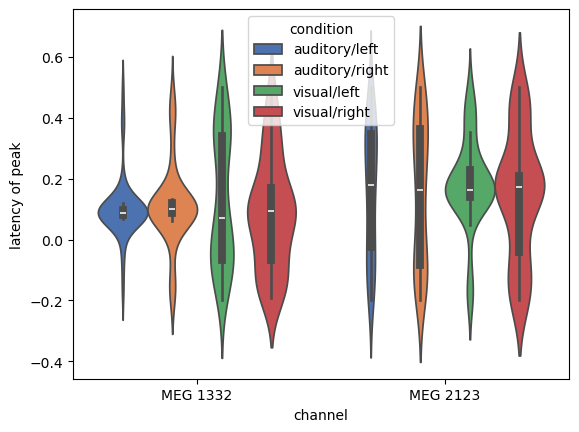

In [9]:
plt.figure()
df = epochs.to_data_frame(time_format=None)
peak_latency = (
    df.filter(regex=r"condition|epoch|MEG 1332|MEG 2123")
    .groupby(["condition", "epoch"])
    .aggregate(lambda x: df["time"].iloc[x.idxmax()])
    .reset_index()
    .melt(
        id_vars=["condition", "epoch"], var_name="channel", value_name="latency of peak"
    )
)
ax = sns.violinplot(
    x="channel",
    y="latency of peak",
    hue="condition",
    data=peak_latency,
    palette="deep",
    saturation=1,
)